In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# импорт модуля pyplot из библиотеки matplotlib
from matplotlib import pyplot as plt


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значение интенсивности в заданной
# точке пространства в соответствие с (9.92)


def Intensity(Lambda, N, A, R0, r):
    # аргументы функции:
    # Lambda - длина волны
    # N - число источников
    # A - вектор, содержащий значения
    #     интенсивностей источников света
    # R0 - матрица, столбцы которой содержат
    #      координаты источников света
    # r  - вектор-столбец, содержащий
    #      координаты точки наблюдения

    N_ksi = 10**3
    ksi = np.linspace(0, 1, N_ksi)

    Rr = np.zeros(N)

    for i in range(N):
        Rr[i] = np.dot((r.T[:] - R0[:, i]), (r.T[:] - R0[:, i])) ** 0.5

    F = np.zeros(N_ksi)
    for i in range(N_ksi):
        Su = 0
        for j in range(N):
            Su = Su + A[j] / Rr[j] * np.cos(
                2 * np.pi / Lambda * Rr[j] - 2 * np.pi * ksi[i]
            )
        F[i] = Su**2
    z = np.trapz(F, ksi)

    return z


In [3]:
# Ячейка № 3

# вычисление значений
#  интенсивности в заданной
# точке пространства в соответствие с (9.92)

# задание числа источников
N = 2

# задание интенсивности источников
A = np.array([1, 1])

# задание значения длины
# световой волны
Lambda = 5000 * 10**-7

# задание координат радиусов-векторов
# точек расположения источников света
# (массивов размерностью 1х3)
R0 = np.array([0, 0, -0.1])
R1 = np.array([0, 0, 0.1])

# создание матрицы
# (массива R размерности 3x2),
# столбцы которой векторы R0, R1
R = np.column_stack([R0.T, R1.T])

# задание параметров координатной сетки
# в плоскости XOZ
Np = 2000
Z_min = -5
Z_max = 5

# вычисление значений z-х координат
# используемой координатной сетки
z = np.linspace(Z_min, Z_max, Np)

# задание х-ой координаты узлов
# координатной сетки
x = 0

# задание y-ой координаты
# узлов координатной сетки
y = 200

# инициализация массив, используемого для
# хранения значений интенсивности
# световой волны
Iwv = np.zeros(Np)

# вычисление значений интенсивности
# в узлах выбранной координатной сетки
for i in range(Np):
    r = np.array([x, y, z[i]])
    Iwv[i] = Intensity(Lambda, N, A, R, r)

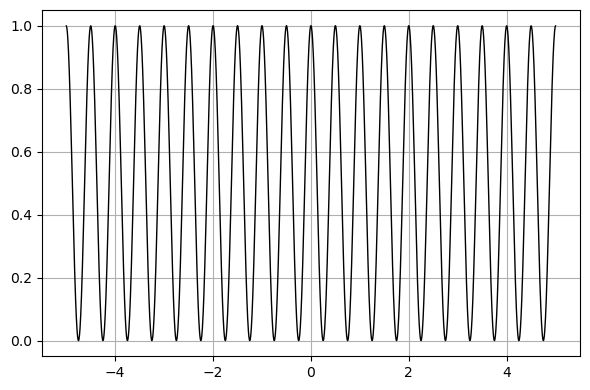

In [ ]:
# Ячейка № 4

# визуализация распределения
# интенсивности световой волны
# в узлах выбранной
# сетки координатной

# определение максимального значения
# интенсивности световой волны
Imax = np.max(Iwv)


# визуализация зависимости
# I(x=0,y=L,Z_min <= z <=Z_max

fig, ax = plt.subplots(figsize=(6, 4), layout="tight")
ax.plot(z, Iwv / Imax, "-k", lw=1)
ax.grid(True)
plt.show()

In [5]:
# Ячейка № 4

# задание функции, возвращающей
# значение интенсивности в заданной
# точке пространства в соответствие с (9.92)


def Intensity_mean(Lambda, N, A, R0, r, Nb):
    # аргументы функции:
    # Lambda - длина волны
    # N - число источников
    # A - вектор, содержащий значения
    #     интенсивностей источников света
    # R0 - матрица, столбцы которой содержат
    #      координаты источников света
    # r  - вектор-столбец, содержащий
    #      координаты точки наблюдения

    Rr = np.zeros(N)

    for i in range(N):
        Rr[i] = np.dot((r.T[:] - R0[:, i]), (r.T[:] - R0[:, i])) ** 0.5

    F = np.zeros(Nb)
    for i in range(Nb):
        Su = 0
        for j in range(N):
            Su = Su + A[j] / Rr[j] * np.cos(
                2 * np.pi / Lambda * Rr[j] - 2 * np.pi / Nb * i
            )
        F[i] = Su**2
    z = np.mean(F)

    return z


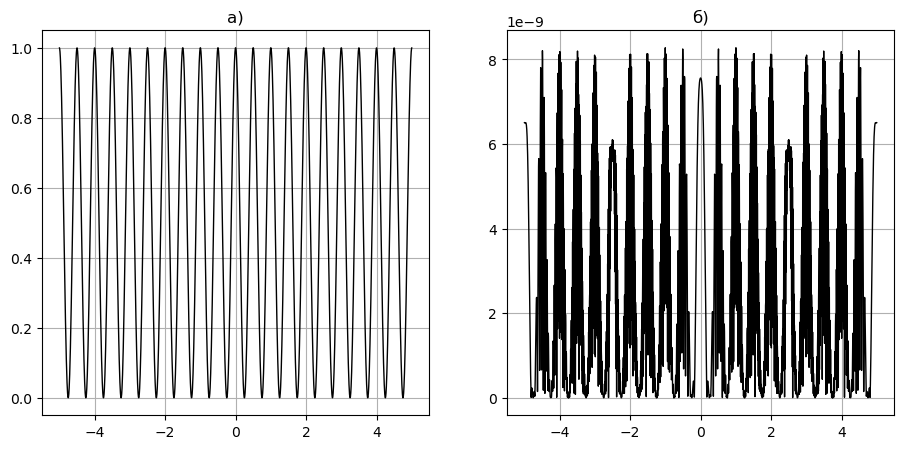

In [ ]:
# Ячейка № 5

# вычисление и визуализация
# относительных модулей разностей
# значений i И I2: |I-I2|/I

Nb = 3
# инициализация массива, используемого для
# хранения значений интенсивности
# световой волны
I2 = np.zeros(Np)

# вычисление значений интенсивности
# в узлах выбранной координатной сетки
for i in range(Np):
    r = np.array([x, y, z[i]])
    I2[i] = Intensity_mean(Lambda, N, A, R, r, Nb)

# определение максимального значения
# интенсивности световой волны
Imax2 = np.max(I2)

fig = plt.figure(figsize=(11, 5))

# визуализация зависимости
# I(x=0,y=L,Z_min <= z <=Z_max
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(z, I2 / Imax2, "-k", lw=1)
ax1.grid(True)
plt.title("a)")

# визуализация абсолютных значений
# разности интенсивностей световой волны,
# вычисленных с помощью численного интегрирования (I)
# и усреднения (I2)
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(z, np.abs(Iwv - I2) / Imax * 100, "-k", lw=1)
ax2.grid(True)
plt.title("б)")

plt.show()

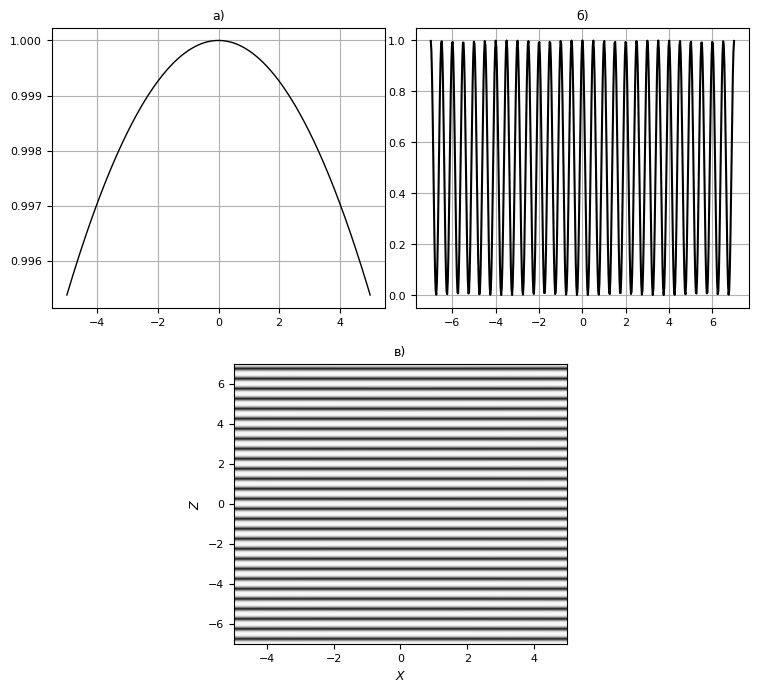

In [ ]:
# Ячейка № 6

# визуализация интенсивности
# световой волны в выбранных
# точках пространства

# задание параметров
# координатной сетки по оси ОХ:
# число узлов (Nx),
# минимальной и максимальной координаты
# сетки Xmin, Xmax
Nx = 501
Xmin = -5
Xmax = 5

# вычисление координат
# узлов сетки по оси ОХ
x = np.linspace(Xmin, Xmax, Nx)

# задание параметров
# координатной сетки по оси ОZ:
# число узлов (Nz),
# минимальной и максимальной координаты
# сетки Zmin, Zmax
Nz = 501
Zmin = -7
Zmax = 7

# вычисление координат
# узлов сетки по оси ОZ
z = np.linspace(Zmin, Zmax, Nz)

# задание числа точек, используемых
# для вычисления усредненного значения
# световой волны
Nb = 3

# инициализация массива, используемого для
# хранения значений интенсивности
# световой волны
I2 = np.zeros([Nx, Nz])

# вычисление значений интенсивности
# в узлах выбранной координатной сетки
for i in range(Nz):
    for j in range(Nx):
        r = np.array([x[j], y, z[i]])
        I2[j, i] = Intensity_mean(Lambda, N, A, R, r, Nb)

# создание матриц, используемых
# для визуализации световой волны
[X, Z] = np.meshgrid(x, z)

# визуализация интенсивности световой волны
# в выбранных точках пространства

fig = plt.figure(figsize=(9, 8))

ax0 = plt.subplot2grid(
    (2, 4),  # размер сетки = 2 ряда по 4 элемента
    (0, 0),  # локация первого элемента
    colspan=2,
)  # этот график займет 2 колонки
# аналогично задаем параметры остальных графиков
ax1 = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax2 = plt.subplot2grid((2, 4), (1, 1), colspan=2)

# задание номера выбранного столбца матрицы I2
Nz2 = 300

# визуализация зависимости I2[x[:],y = 200,Nz2]
Imax2 = np.max(I2[:, Nz2])
ax0.plot(x[:], I2[:, Nz2] / Imax2, "-k", lw=1)
ax0.grid(True)
ax0.tick_params(axis="both", which="major", labelsize=8)
ax0.set_title("а)", fontsize=9)

# задание номера выбранной строки матрицы I2
Nx2 = 300
Imax2 = np.max(I2[Nx2, :])
# визуализация зависимости I2[x[Nx],y=200,z[:]]
ax1.plot(z[:], I2[Nx2, :] / Imax2, "black")
ax1.grid(True)
ax1.tick_params(axis="both", which="major", labelsize=8)
ax1.set_title("б)", fontsize=9)

# визуализация в виде карты линий уровня
# распределения интенсивности световой волны
# в плоскости XOZ
CS = ax2.contour(X, Z, I2.T, levels=33, cmap="gray")
ax2.tick_params(axis="both", which="major", labelsize=8)
ax2.set_title("в)", fontsize=9)
ax2.set_xlabel(r"$X$", fontsize=9)
ax2.set_ylabel(r"$Z$", fontsize=9)

plt.show()
